# NB02: Spatial Analysis of Sediment Communities

**Goal**: Test whether 16S community similarity across the 9 SSO wells recapitulates their spatial arrangement. Identify well pairs that deviate from distance-decay expectations.

**Analyses**:
1. Bray-Curtis dissimilarity matrix (well-aggregated sediment profiles)
2. Mantel test: community dissimilarity vs geographic distance
3. NMDS ordination of community dissimilarity
4. Procrustes analysis: rotate NMDS to match physical grid
5. Residual analysis: which well pairs deviate from distance-decay?

**Inputs**: Community matrices and distance matrix from NB01  
**Outputs**: Figures + `data/spatial_stats.csv`, `data/bc_dissimilarity_sediment.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import braycurtis, squareform, pdist
from scipy.stats import spearmanr, pearsonr
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIG = Path('../figures')

# Grid metadata
GRID = {
    'SSO-U1': (2, 0), 'SSO-U2': (2, 1), 'SSO-U3': (2, 2),
    'SSO-M4': (1, 0), 'SSO-M5': (1, 1), 'SSO-M6': (1, 2),
    'SSO-L7': (0, 0), 'SSO-L8': (0, 1), 'SSO-L9': (0, 2),
}
ROW_COLORS = {'U': '#2196F3', 'M': '#4CAF50', 'L': '#F44336'}
ROW_LABELS = {'U': 'Upper', 'M': 'Middle', 'L': 'Lower'}

print("Libraries loaded")

Libraries loaded


In [2]:
# Load community matrices and distance matrix from NB01
sed_asv = pd.read_csv(DATA / 'community_matrix_sediment_asv.csv', index_col=0)
sed_phylum = pd.read_csv(DATA / 'community_matrix_sediment_phylum.csv', index_col=0)
geo_dist_df = pd.read_csv(DATA / 'well_distances.csv', index_col=0)

# Ensure consistent well ordering
well_order = ['SSO-U1', 'SSO-U2', 'SSO-U3', 'SSO-M4', 'SSO-M5', 'SSO-M6',
              'SSO-L7', 'SSO-L8', 'SSO-L9']
sed_asv = sed_asv.loc[well_order]
sed_phylum = sed_phylum.loc[well_order]
geo_dist_df = geo_dist_df.loc[well_order, well_order]

print(f"Sediment ASV matrix: {sed_asv.shape[0]} wells x {sed_asv.shape[1]:,} ASVs")
print(f"Sediment phylum matrix: {sed_phylum.shape}")
print(f"Geographic distance matrix: {geo_dist_df.shape}")
print(f"Total reads per well (range): {int(sed_asv.sum(axis=1).min()):,} - {int(sed_asv.sum(axis=1).max()):,}")

Sediment ASV matrix: 9 wells x 23,458 ASVs
Sediment phylum matrix: (9, 85)
Geographic distance matrix: (9, 9)
Total reads per well (range): 97,104 - 121,380


## 1. Bray-Curtis Dissimilarity

Compute pairwise Bray-Curtis dissimilarity between all 9 wells using relative abundance profiles. Bray-Curtis ranges from 0 (identical) to 1 (no shared taxa).

In [3]:
# Convert to relative abundance
sed_rel = sed_asv.div(sed_asv.sum(axis=1), axis=0)

# Bray-Curtis dissimilarity
bc_condensed = pdist(sed_rel.values, metric='braycurtis')
bc_matrix = squareform(bc_condensed)
bc_df = pd.DataFrame(bc_matrix, index=well_order, columns=well_order).round(4)
bc_df.to_csv(DATA / 'bc_dissimilarity_sediment.csv')

print("Bray-Curtis dissimilarity matrix (sediment, well-aggregated):")
print(bc_df.round(3).to_string())
print(f"\nMean BC: {bc_condensed.mean():.3f} (range: {bc_condensed.min():.3f} - {bc_condensed.max():.3f})")

Bray-Curtis dissimilarity matrix (sediment, well-aggregated):
        SSO-U1  SSO-U2  SSO-U3  SSO-M4  SSO-M5  SSO-M6  SSO-L7  SSO-L8  SSO-L9
SSO-U1   0.000   0.703   0.786   0.666   0.725   0.752   0.687   0.753   0.791
SSO-U2   0.703   0.000   0.754   0.730   0.714   0.781   0.718   0.758   0.831
SSO-U3   0.786   0.754   0.000   0.871   0.722   0.558   0.646   0.776   0.872
SSO-M4   0.666   0.730   0.871   0.000   0.760   0.840   0.800   0.762   0.778
SSO-M5   0.725   0.714   0.722   0.760   0.000   0.733   0.668   0.700   0.793
SSO-M6   0.752   0.781   0.558   0.840   0.733   0.000   0.615   0.730   0.798
SSO-L7   0.687   0.718   0.646   0.800   0.668   0.615   0.000   0.742   0.842
SSO-L8   0.753   0.758   0.776   0.762   0.700   0.730   0.742   0.000   0.750
SSO-L9   0.791   0.831   0.872   0.778   0.793   0.798   0.842   0.750   0.000

Mean BC: 0.747 (range: 0.558 - 0.872)


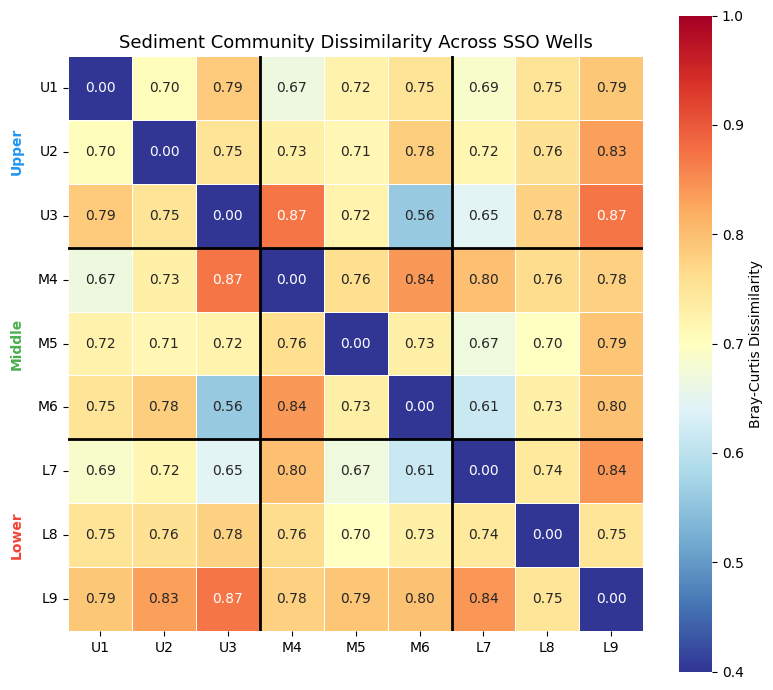

Saved: figures/bc_heatmap_sediment.png


In [4]:
# Heatmap of Bray-Curtis dissimilarity with row grouping
fig, ax = plt.subplots(figsize=(8, 7))

# Annotate with values
sns.heatmap(bc_df, annot=True, fmt='.2f', cmap='RdYlBu_r', vmin=0.4, vmax=1.0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Bray-Curtis Dissimilarity'})

# Add row group separators
for pos in [3, 6]:  # After U3, after M6
    ax.axhline(y=pos, color='black', linewidth=2)
    ax.axvline(x=pos, color='black', linewidth=2)

# Label row groups
ax.text(-0.8, 1.5, 'Upper', ha='center', va='center', fontsize=10, fontweight='bold',
        rotation=90, color=ROW_COLORS['U'])
ax.text(-0.8, 4.5, 'Middle', ha='center', va='center', fontsize=10, fontweight='bold',
        rotation=90, color=ROW_COLORS['M'])
ax.text(-0.8, 7.5, 'Lower', ha='center', va='center', fontsize=10, fontweight='bold',
        rotation=90, color=ROW_COLORS['L'])

ax.set_title('Sediment Community Dissimilarity Across SSO Wells', fontsize=13)
# Shorten tick labels
short = [w.replace('SSO-', '') for w in well_order]
ax.set_xticklabels(short, rotation=0)
ax.set_yticklabels(short, rotation=0)

plt.tight_layout()
plt.savefig(FIG / 'bc_heatmap_sediment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/bc_heatmap_sediment.png")

## 2. Mantel Test: Distance-Decay of Community Similarity

Test H1a: does community dissimilarity increase with geographic distance?

We use a permutation-based Mantel test (Spearman correlation between distance matrices, with 9999 permutations for the p-value).

In [5]:
def mantel_test(dist1, dist2, n_perm=9999):
    """Permutation-based Mantel test (Spearman) between two distance matrices."""
    n = dist1.shape[0]
    # Extract upper triangle (condensed form)
    idx = np.triu_indices(n, k=1)
    x = dist1[idx]
    y = dist2[idx]
    
    observed_rho, _ = spearmanr(x, y)
    
    # Permutation test
    count_ge = 0
    for _ in range(n_perm):
        perm = np.random.permutation(n)
        d2_perm = dist2[np.ix_(perm, perm)]
        y_perm = d2_perm[idx]
        rho_perm, _ = spearmanr(x, y_perm)
        if rho_perm >= observed_rho:
            count_ge += 1
    
    p_value = (count_ge + 1) / (n_perm + 1)
    return observed_rho, p_value, x, y

geo_matrix = geo_dist_df.values

np.random.seed(42)
rho, p_val, geo_upper, bc_upper = mantel_test(geo_matrix, bc_matrix, n_perm=9999)
print(f"Mantel test (Spearman):")
print(f"  rho = {rho:.3f}")
print(f"  p   = {p_val:.4f}  (9999 permutations)")
print(f"  n pairs = {len(geo_upper)}")

if p_val < 0.05:
    print(f"\n  → Significant distance-decay (p < 0.05): community dissimilarity")
    print(f"    increases with geographic distance across the SSO grid.")
else:
    print(f"\n  → Not significant at p < 0.05: no detectable distance-decay.")

Mantel test (Spearman):
  rho = 0.323
  p   = 0.0293  (9999 permutations)
  n pairs = 36

  → Significant distance-decay (p < 0.05): community dissimilarity
    increases with geographic distance across the SSO grid.


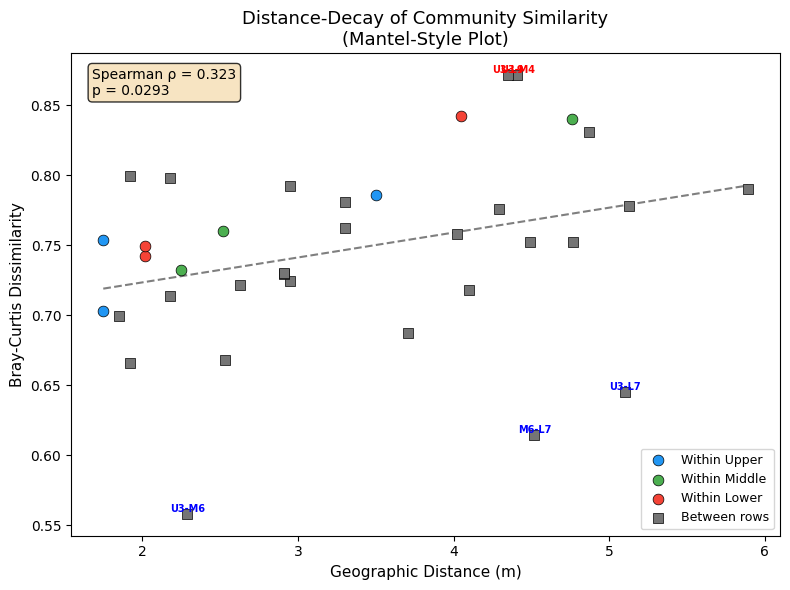

Saved: figures/mantel_distance_decay.png


In [6]:
# Distance-decay scatter plot with pair annotations
fig, ax = plt.subplots(figsize=(8, 6))

# Color pairs by spatial relationship
pair_labels = []
pair_colors = []
pair_names = []
idx_upper = np.triu_indices(9, k=1)
for k in range(len(geo_upper)):
    i, j = idx_upper[0][k], idx_upper[1][k]
    w1, w2 = well_order[i], well_order[j]
    r1, r2 = w1[4], w2[4]  # U, M, or L
    name = f"{w1.replace('SSO-','')}-{w2.replace('SSO-','')}"
    pair_names.append(name)
    
    if r1 == r2:
        pair_labels.append(f'Within {ROW_LABELS[r1]}')
        pair_colors.append(ROW_COLORS[r1])
    else:
        pair_labels.append('Between rows')
        pair_colors.append('#757575')

for label in ['Within Upper', 'Within Middle', 'Within Lower', 'Between rows']:
    mask = [l == label for l in pair_labels]
    if any(mask):
        x_sub = geo_upper[mask]
        y_sub = bc_upper[mask]
        color = [pair_colors[i] for i, m in enumerate(mask) if m][0]
        marker = 'o' if 'Within' in label else 's'
        ax.scatter(x_sub, y_sub, c=color, label=label, s=60, marker=marker, 
                   edgecolors='k', linewidth=0.5, zorder=3)

# Linear regression line
from numpy.polynomial import polynomial as P
coeffs = np.polyfit(geo_upper, bc_upper, 1)
x_line = np.linspace(geo_upper.min(), geo_upper.max(), 100)
ax.plot(x_line, np.polyval(coeffs, x_line), 'k--', alpha=0.5, linewidth=1.5)

# Annotate notable outlier pairs (high residual)
residuals = bc_upper - np.polyval(coeffs, geo_upper)
outlier_idx = np.argsort(np.abs(residuals))[-5:]  # top 5 outliers
for oi in outlier_idx:
    ax.annotate(pair_names[oi], (geo_upper[oi], bc_upper[oi]),
                fontsize=7, ha='center', va='bottom', 
                color='red' if residuals[oi] > 0 else 'blue', fontweight='bold')

ax.set_xlabel('Geographic Distance (m)', fontsize=11)
ax.set_ylabel('Bray-Curtis Dissimilarity', fontsize=11)
ax.set_title('Distance-Decay of Community Similarity\n(Mantel-Style Plot)', fontsize=13)

# Stats annotation
ax.text(0.03, 0.97, f"Spearman ρ = {rho:.3f}\np = {p_val:.4f}",
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(FIG / 'mantel_distance_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/mantel_distance_decay.png")

## 3. NMDS Ordination

Non-metric multidimensional scaling maps the 9-well dissimilarity matrix into 2D. We compare the resulting ordination to the physical grid to see which wells cluster together in community space vs physical space.

In [7]:
# NMDS ordination (2D)
nmds = MDS(n_components=2, dissimilarity='precomputed', metric=False,
           random_state=42, n_init=20, max_iter=1000, normalized_stress='auto')
coords = nmds.fit_transform(bc_matrix)
stress = nmds.stress_

print(f"NMDS stress: {stress:.4f}")
if stress < 0.1:
    print("  → Good representation (stress < 0.1)")
elif stress < 0.2:
    print("  → Acceptable representation (stress < 0.2)")
else:
    print("  → Poor representation (stress ≥ 0.2) — interpret with caution")

nmds_df = pd.DataFrame(coords, index=well_order, columns=['NMDS1', 'NMDS2'])

NMDS stress: 0.0674
  → Good representation (stress < 0.1)


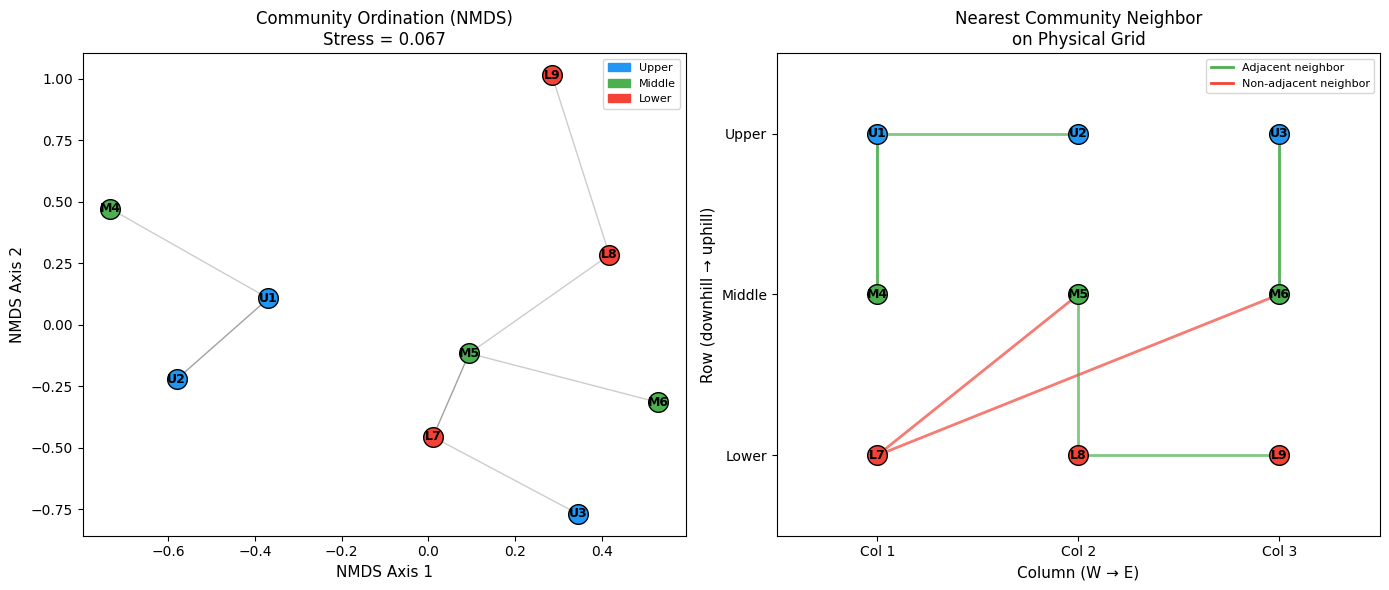

Saved: figures/nmds_vs_grid.png


In [8]:
# Side-by-side: NMDS ordination vs physical grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel A: NMDS ordination ---
for well in well_order:
    row_label = well[4]
    c = ROW_COLORS[row_label]
    x, y = nmds_df.loc[well, 'NMDS1'], nmds_df.loc[well, 'NMDS2']
    ax1.scatter(x, y, c=c, s=200, edgecolors='k', linewidth=1, zorder=5)
    ax1.annotate(well.replace('SSO-', ''), (x, y), ha='center', va='center',
                fontsize=9, fontweight='bold', zorder=6)

# Connect nearest NMDS neighbors with lines
from scipy.spatial.distance import cdist
nmds_dists = cdist(coords, coords)
for i in range(9):
    # Connect each well to its nearest community neighbor
    dists_i = nmds_dists[i].copy()
    dists_i[i] = np.inf
    j = np.argmin(dists_i)
    ax1.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
            'k-', alpha=0.2, linewidth=1)

ax1.set_xlabel('NMDS Axis 1', fontsize=11)
ax1.set_ylabel('NMDS Axis 2', fontsize=11)
ax1.set_title(f'Community Ordination (NMDS)\nStress = {stress:.3f}', fontsize=12)

# --- Panel B: Physical grid with nearest community neighbor ---
for well in well_order:
    row_label = well[4]
    c = ROW_COLORS[row_label]
    r, col = GRID[well]
    ax2.scatter(col, r, c=c, s=200, edgecolors='k', linewidth=1, zorder=5)
    ax2.annotate(well.replace('SSO-', ''), (col, r), ha='center', va='center',
                fontsize=9, fontweight='bold', zorder=6)

# Draw lines to nearest COMMUNITY neighbor on the physical grid
for i in range(9):
    bc_dists_i = bc_matrix[i].copy()
    bc_dists_i[i] = np.inf
    j = np.argmin(bc_dists_i)
    w1, w2 = well_order[i], well_order[j]
    r1, c1 = GRID[w1]
    r2, c2 = GRID[w2]
    # Color red if nearest community neighbor is NOT a physical neighbor
    is_adjacent = abs(r1-r2) + abs(c1-c2) == 1
    color = '#4CAF50' if is_adjacent else '#F44336'
    ax2.plot([c1, c2], [r1, r2], '-', color=color, alpha=0.7, linewidth=2)

ax2.set_xlabel('Column (W → E)', fontsize=11)
ax2.set_ylabel('Row (downhill → uphill)', fontsize=11)
ax2.set_title('Nearest Community Neighbor\non Physical Grid', fontsize=12)
ax2.set_xlim(-0.5, 2.5); ax2.set_ylim(-0.5, 2.5)
ax2.set_xticks([0, 1, 2]); ax2.set_xticklabels(['Col 1', 'Col 2', 'Col 3'])
ax2.set_yticks([0, 1, 2]); ax2.set_yticklabels(['Lower', 'Middle', 'Upper'])

# Legend
handles = [mpatches.Patch(color=c, label=l) for l, c in 
           [('Upper', '#2196F3'), ('Middle', '#4CAF50'), ('Lower', '#F44336')]]
ax1.legend(handles=handles, fontsize=8, loc='best')
# Neighbor legend
from matplotlib.lines import Line2D
leg_handles = [Line2D([0],[0], color='#4CAF50', linewidth=2, label='Adjacent neighbor'),
               Line2D([0],[0], color='#F44336', linewidth=2, label='Non-adjacent neighbor')]
ax2.legend(handles=leg_handles, fontsize=8, loc='best')

plt.tight_layout()
plt.savefig(FIG / 'nmds_vs_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/nmds_vs_grid.png")

## 4. Procrustes Analysis

Procrustes analysis finds the optimal rotation, reflection, and scaling to superimpose the NMDS ordination onto the physical grid coordinates. The residual after alignment measures how well community structure matches spatial arrangement. A significant Procrustes correlation (via PROTEST permutation test) confirms the match.

In [9]:
from scipy.spatial import procrustes

# Physical grid coordinates (normalized to same scale as NMDS)
grid_coords = np.array([GRID[w] for w in well_order], dtype=float)

# Procrustes: align NMDS to physical grid
mtx1, mtx2, disparity = procrustes(grid_coords, coords)

print(f"Procrustes disparity (sum of squared residuals): {disparity:.4f}")
print(f"  Lower = better match between community ordination and physical grid")

# PROTEST: permutation test for Procrustes significance
n_perm = 9999
np.random.seed(42)
count_le = 0
for _ in range(n_perm):
    perm = np.random.permutation(9)
    _, _, d_perm = procrustes(grid_coords, coords[perm])
    if d_perm <= disparity:
        count_le += 1

p_procrustes = (count_le + 1) / (n_perm + 1)
m2 = 1 - disparity  # Procrustes correlation analog
print(f"\nPROTEST permutation test:")
print(f"  m² = {m2:.4f} (Procrustes correlation)")
print(f"  p  = {p_procrustes:.4f} ({n_perm} permutations)")

if p_procrustes < 0.05:
    print("  → Significant: community ordination matches physical grid (p < 0.05)")
else:
    print("  → Not significant: community ordination does not match physical grid")

Procrustes disparity (sum of squared residuals): 0.6210
  Lower = better match between community ordination and physical grid



PROTEST permutation test:
  m² = 0.3790 (Procrustes correlation)
  p  = 0.0796 (9999 permutations)
  → Not significant: community ordination does not match physical grid


  SSO-U1: residual = 0.327
  SSO-U2: residual = 0.215
  SSO-U3: residual = 0.148
  SSO-M4: residual = 0.061
  SSO-M5: residual = 0.046
  SSO-M6: residual = 0.106
  SSO-L7: residual = 0.541
  SSO-L8: residual = 0.184
  SSO-L9: residual = 0.319


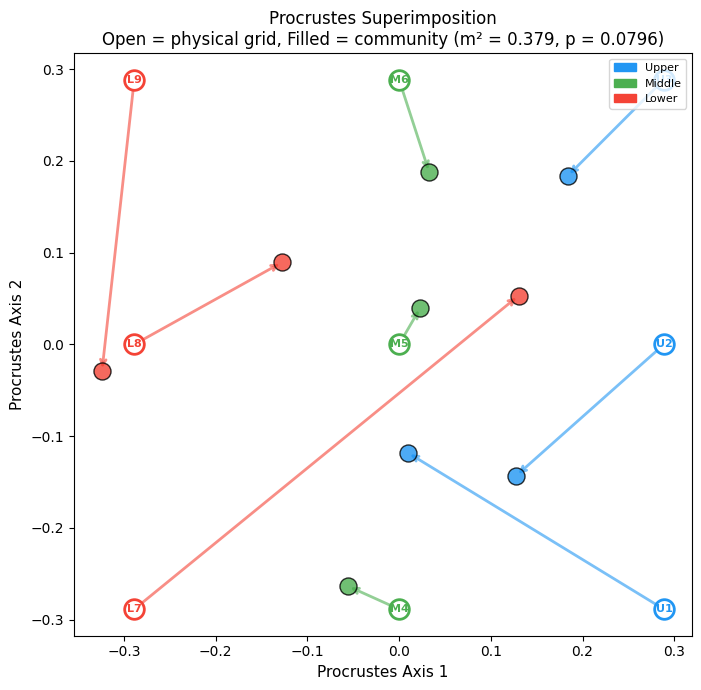


Saved: figures/procrustes_overlay.png


In [10]:
# Procrustes superimposition figure
fig, ax = plt.subplots(figsize=(8, 7))

# Draw arrows from physical grid position (target) to NMDS-aligned position
for i, well in enumerate(well_order):
    row_label = well[4]
    c = ROW_COLORS[row_label]
    
    # Physical grid (target = mtx1)
    gx, gy = mtx1[i]
    # NMDS rotated (aligned = mtx2)
    nx, ny = mtx2[i]
    
    # Arrow from grid to NMDS
    ax.annotate('', xy=(nx, ny), xytext=(gx, gy),
                arrowprops=dict(arrowstyle='->', color=c, lw=2, alpha=0.6))
    
    # Grid position (open circle)
    ax.scatter(gx, gy, c='white', s=200, edgecolors=c, linewidth=2, zorder=4)
    ax.annotate(well.replace('SSO-', ''), (gx, gy), ha='center', va='center',
                fontsize=8, color=c, fontweight='bold', zorder=5)
    
    # NMDS position (filled circle)
    ax.scatter(nx, ny, c=c, s=150, edgecolors='k', linewidth=1, zorder=4, alpha=0.8)

# Per-well residual
residuals_per_well = np.sqrt(np.sum((mtx1 - mtx2)**2, axis=1))
for i, well in enumerate(well_order):
    print(f"  {well}: residual = {residuals_per_well[i]:.3f}")

ax.set_xlabel('Procrustes Axis 1', fontsize=11)
ax.set_ylabel('Procrustes Axis 2', fontsize=11)
ax.set_title(f'Procrustes Superimposition\n'
             f'Open = physical grid, Filled = community (m² = {m2:.3f}, p = {p_procrustes:.4f})',
             fontsize=12)
ax.set_aspect('equal')

handles = [mpatches.Patch(color=c, label=l) for l, c in 
           [('Upper', '#2196F3'), ('Middle', '#4CAF50'), ('Lower', '#F44336')]]
ax.legend(handles=handles, fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'procrustes_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: figures/procrustes_overlay.png")

## 5. Residual Analysis: Which Well Pairs Deviate from Distance-Decay?

Identify pairs whose community dissimilarity is much higher or lower than expected from geographic distance. These deviations point to environmental discontinuities or hydrological connections.

In [11]:
# Build a table of all pairwise comparisons with residuals
pairs = []
idx = np.triu_indices(9, k=1)
for k in range(len(idx[0])):
    i, j = idx[0][k], idx[1][k]
    w1, w2 = well_order[i], well_order[j]
    r1, c1 = GRID[w1]
    r2, c2 = GRID[w2]
    
    geo_d = geo_matrix[i, j]
    bc_d = bc_matrix[i, j]
    expected_bc = np.polyval(coeffs, geo_d)
    resid = bc_d - expected_bc
    
    # Categorize spatial relationship
    row_diff = abs(r1 - r2)
    col_diff = abs(c1 - c2)
    if row_diff == 0:
        rel = 'same_row'
    elif col_diff == 0:
        rel = 'same_col'
    else:
        rel = 'diagonal'
    
    pairs.append({
        'well1': w1.replace('SSO-', ''),
        'well2': w2.replace('SSO-', ''),
        'geo_dist_m': round(geo_d, 2),
        'bc_dissim': round(bc_d, 4),
        'expected_bc': round(expected_bc, 4),
        'residual': round(resid, 4),
        'spatial_rel': rel,
        'row_diff': row_diff,
        'col_diff': col_diff,
    })

pairs_df = pd.DataFrame(pairs).sort_values('residual')
pairs_df.to_csv(DATA / 'spatial_stats.csv', index=False)

print("All pairwise comparisons (sorted by residual):")
print(f"{'Pair':<10} {'Geo(m)':>7} {'BC':>7} {'Expected':>9} {'Residual':>9} {'Relation':<12}")
print("-" * 60)
for _, r in pairs_df.iterrows():
    flag = ""
    if abs(r['residual']) > pairs_df['residual'].std() * 1.5:
        flag = " ◀" if r['residual'] < 0 else " ▶"
    print(f"{r['well1']}-{r['well2']:<6} {r['geo_dist_m']:>7.2f} {r['bc_dissim']:>7.3f} "
          f"{r['expected_bc']:>9.3f} {r['residual']:>+9.4f} {r['spatial_rel']:<12}{flag}")

print(f"\nResidual SD: {pairs_df['residual'].std():.4f}")
print(f"\n◀ = more similar than expected (possible hydrological connection)")
print(f"▶ = more different than expected (possible environmental discontinuity)")

All pairwise comparisons (sorted by residual):
Pair        Geo(m)      BC  Expected  Residual Relation    
------------------------------------------------------------
U3-M6        2.29   0.558     0.729   -0.1704 same_col     ◀
M6-L7        4.52   0.615     0.768   -0.1537 diagonal     ◀
U3-L7        5.10   0.646     0.779   -0.1331 diagonal     ◀
U1-L7        3.71   0.687     0.754   -0.0669 same_col    
M5-L7        2.53   0.668     0.733   -0.0650 diagonal    
U1-M4        1.92   0.666     0.722   -0.0561 same_col    
U2-L7        4.10   0.718     0.761   -0.0427 diagonal    
M5-L8        1.85   0.700     0.721   -0.0212 same_col    
U1-M6        4.77   0.752     0.773   -0.0205 diagonal    
U1-U2        1.75   0.703     0.719   -0.0157 same_row    
U1-M5        2.95   0.725     0.741   -0.0156 diagonal    
U1-L8        4.49   0.753     0.768   -0.0152 diagonal    
U3-M5        2.63   0.722     0.735   -0.0132 diagonal    
U2-M5        2.18   0.714     0.727   -0.0126 same_col    


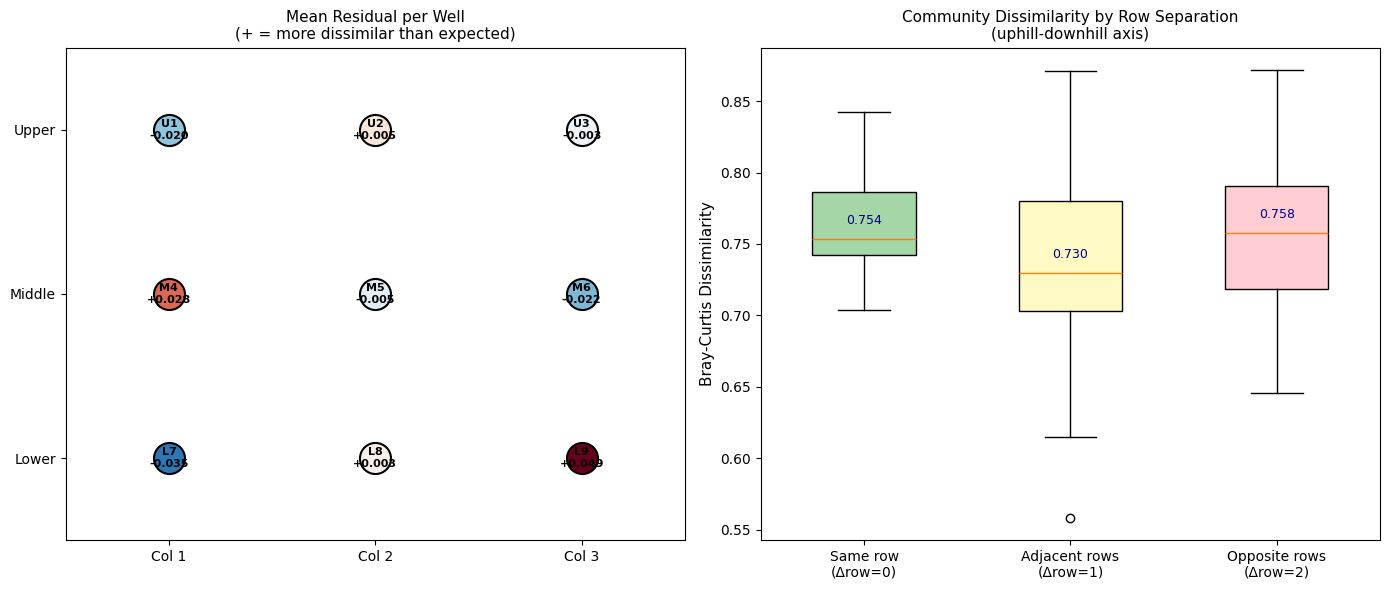

Saved: figures/residual_analysis.png


In [12]:
# Visualize residuals on the physical grid
# For each well, compute mean residual (positive = more dissimilar than expected)
well_mean_resid = {}
for well in well_order:
    short = well.replace('SSO-', '')
    mask = (pairs_df['well1'] == short) | (pairs_df['well2'] == short)
    well_mean_resid[well] = pairs_df.loc[mask, 'residual'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel A: Mean residual per well on grid ---
resid_vals = [well_mean_resid[w] for w in well_order]
vmax = max(abs(min(resid_vals)), abs(max(resid_vals)))

for well in well_order:
    r, c = GRID[well]
    val = well_mean_resid[well]
    color = plt.cm.RdBu_r((val + vmax) / (2 * vmax))  # diverging colormap
    ax1.scatter(c, r, c=[color], s=500, edgecolors='k', linewidth=1.5, zorder=5)
    ax1.annotate(f"{well.replace('SSO-','')}\n{val:+.3f}", (c, r), 
                ha='center', va='center', fontsize=8, fontweight='bold', zorder=6)

ax1.set_title('Mean Residual per Well\n(+ = more dissimilar than expected)', fontsize=11)
ax1.set_xlim(-0.5, 2.5); ax1.set_ylim(-0.5, 2.5)
ax1.set_xticks([0,1,2]); ax1.set_xticklabels(['Col 1','Col 2','Col 3'])
ax1.set_yticks([0,1,2]); ax1.set_yticklabels(['Lower','Middle','Upper'])

# --- Panel B: Row-level BC dissimilarity ---
# Within-row vs between-row dissimilarity
within_row = pairs_df[pairs_df['row_diff'] == 0]['bc_dissim']
between_adj = pairs_df[(pairs_df['row_diff'] == 1)]['bc_dissim']
between_far = pairs_df[(pairs_df['row_diff'] == 2)]['bc_dissim']

box_data = [within_row.values, between_adj.values, between_far.values]
bp = ax2.boxplot(box_data, labels=['Same row\n(Δrow=0)', 'Adjacent rows\n(Δrow=1)', 
                                     'Opposite rows\n(Δrow=2)'],
                patch_artist=True, widths=0.5)
colors_box = ['#A5D6A7', '#FFF9C4', '#FFCDD2']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

ax2.set_ylabel('Bray-Curtis Dissimilarity', fontsize=11)
ax2.set_title('Community Dissimilarity by Row Separation\n(uphill-downhill axis)', fontsize=11)

# Annotate medians
for i, data in enumerate(box_data):
    ax2.text(i+1, np.median(data) + 0.01, f'{np.median(data):.3f}', 
            ha='center', fontsize=9, color='navy')

plt.tight_layout()
plt.savefig(FIG / 'residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/residual_analysis.png")

## 6. Directional Analysis: Uphill-Downhill vs East-West

The SSO grid sits on a hillslope. Test whether community turnover is stronger along the uphill-downhill axis (rows) vs the east-west axis (columns). Stronger row effects would suggest the hillslope gradient (hydrology, redox) dominates, while column effects would suggest lateral heterogeneity.

In [13]:
# Directional analysis: row distance vs column distance effect on BC
pairs_df['row_only'] = (pairs_df['row_diff'] > 0) & (pairs_df['col_diff'] == 0)
pairs_df['col_only'] = (pairs_df['row_diff'] == 0) & (pairs_df['col_diff'] > 0)

# Mean BC for same-column pairs (pure row effect) vs same-row pairs (pure column effect)
row_effect = pairs_df[pairs_df['row_only']]['bc_dissim']
col_effect = pairs_df[pairs_df['col_only']]['bc_dissim']

print("Directional analysis of community turnover:")
print(f"\n  Same-column pairs (pure uphill-downhill, n={len(row_effect)}):")
print(f"    Mean BC = {row_effect.mean():.4f} ± {row_effect.std():.4f}")
print(f"\n  Same-row pairs (pure east-west, n={len(col_effect)}):")
print(f"    Mean BC = {col_effect.mean():.4f} ± {col_effect.std():.4f}")

# Compare: is the row effect stronger?
from scipy.stats import mannwhitneyu
if len(row_effect) > 0 and len(col_effect) > 0:
    stat, p_dir = mannwhitneyu(row_effect, col_effect, alternative='greater')
    print(f"\n  Mann-Whitney U test (row > column):")
    print(f"    U = {stat:.1f}, p = {p_dir:.4f}")
    if p_dir < 0.05:
        print(f"    → Uphill-downhill turnover is significantly greater than east-west")
    else:
        print(f"    → No significant difference in directional turnover")

# Also check: Mantel with row-distance-only and column-distance-only matrices
row_dist = np.zeros((9, 9))
col_dist = np.zeros((9, 9))
for i, w1 in enumerate(well_order):
    for j, w2 in enumerate(well_order):
        r1, c1 = GRID[w1]
        r2, c2 = GRID[w2]
        row_dist[i, j] = abs(r1 - r2)
        col_dist[i, j] = abs(c1 - c2)

np.random.seed(42)
rho_row, p_row, _, _ = mantel_test(row_dist, bc_matrix, n_perm=9999)
rho_col, p_col, _, _ = mantel_test(col_dist, bc_matrix, n_perm=9999)

print(f"\n  Mantel (BC ~ row distance): rho = {rho_row:.3f}, p = {p_row:.4f}")
print(f"  Mantel (BC ~ col distance): rho = {rho_col:.3f}, p = {p_col:.4f}")

if rho_row > rho_col:
    print(f"\n  → Uphill-downhill axis explains more community variation (rho {rho_row:.3f} vs {rho_col:.3f})")
else:
    print(f"\n  → East-west axis explains more community variation (rho {rho_col:.3f} vs {rho_row:.3f})")

Directional analysis of community turnover:

  Same-column pairs (pure uphill-downhill, n=9):
    Mean BC = 0.7280 ± 0.0914

  Same-row pairs (pure east-west, n=9):
    Mean BC = 0.7678 ± 0.0470

  Mann-Whitney U test (row > column):
    U = 29.0, p = 0.8553
    → No significant difference in directional turnover



  Mantel (BC ~ row distance): rho = -0.049, p = 0.5798
  Mantel (BC ~ col distance): rho = 0.227, p = 0.0919

  → East-west axis explains more community variation (rho 0.227 vs -0.049)


## 7. Summary Statistics

In [14]:
print("=" * 60)
print("NB02 SEDIMENT SPATIAL ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n1. BRAY-CURTIS DISSIMILARITY")
print(f"   Mean: {bc_condensed.mean():.3f}  Range: {bc_condensed.min():.3f} - {bc_condensed.max():.3f}")
print(f"   Most similar pair:  {pairs_df.iloc[0]['well1']}-{pairs_df.iloc[0]['well2']} (BC={pairs_df.iloc[0]['bc_dissim']:.3f})")
print(f"   Most dissimilar:    {pairs_df.iloc[-1]['well1']}-{pairs_df.iloc[-1]['well2']} (BC={pairs_df.iloc[-1]['bc_dissim']:.3f})")

print(f"\n2. MANTEL TEST (distance-decay)")
print(f"   Spearman rho = {rho:.3f}, p = {p_val:.4f}")
print(f"   {'SIGNIFICANT' if p_val < 0.05 else 'NOT SIGNIFICANT'} at alpha = 0.05")

print(f"\n3. PROCRUSTES (community vs grid)")
print(f"   m² = {m2:.4f}, p = {p_procrustes:.4f}")
print(f"   {'SIGNIFICANT' if p_procrustes < 0.05 else 'NOT SIGNIFICANT'} at alpha = 0.05")

print(f"\n4. DIRECTIONAL ANALYSIS")
print(f"   Row (uphill-downhill) Mantel: rho = {rho_row:.3f}, p = {p_row:.4f}")
print(f"   Col (east-west) Mantel:       rho = {rho_col:.3f}, p = {p_col:.4f}")

print(f"\n5. NMDS")
print(f"   Stress = {stress:.4f}")

# Identify the biggest deviations
print(f"\n6. NOTABLE DEVIATIONS FROM DISTANCE-DECAY")
resid_std = pairs_df['residual'].std()
outliers = pairs_df[abs(pairs_df['residual']) > 1.5 * resid_std]
if len(outliers) > 0:
    for _, r in outliers.iterrows():
        direction = "MORE SIMILAR" if r['residual'] < 0 else "MORE DIFFERENT"
        print(f"   {r['well1']}-{r['well2']}: {direction} than expected "
              f"(resid={r['residual']:+.4f}, BC={r['bc_dissim']:.3f})")
else:
    print("   No pairs exceed 1.5 SD threshold")

print(f"\nFiles saved:")
print(f"  data/bc_dissimilarity_sediment.csv")
print(f"  data/spatial_stats.csv")
print(f"  figures/bc_heatmap_sediment.png")
print(f"  figures/mantel_distance_decay.png")
print(f"  figures/nmds_vs_grid.png")
print(f"  figures/procrustes_overlay.png")
print(f"  figures/residual_analysis.png")

NB02 SEDIMENT SPATIAL ANALYSIS SUMMARY

1. BRAY-CURTIS DISSIMILARITY
   Mean: 0.747  Range: 0.558 - 0.872
   Most similar pair:  U3-M6 (BC=0.558)
   Most dissimilar:    U3-L9 (BC=0.872)

2. MANTEL TEST (distance-decay)
   Spearman rho = 0.323, p = 0.0293
   SIGNIFICANT at alpha = 0.05

3. PROCRUSTES (community vs grid)
   m² = 0.3790, p = 0.0796
   NOT SIGNIFICANT at alpha = 0.05

4. DIRECTIONAL ANALYSIS
   Row (uphill-downhill) Mantel: rho = -0.049, p = 0.5798
   Col (east-west) Mantel:       rho = 0.227, p = 0.0919

5. NMDS
   Stress = 0.0674

6. NOTABLE DEVIATIONS FROM DISTANCE-DECAY
   U3-M6: MORE SIMILAR than expected (resid=-0.1704, BC=0.558)
   M6-L7: MORE SIMILAR than expected (resid=-0.1537, BC=0.615)
   U3-L7: MORE SIMILAR than expected (resid=-0.1331, BC=0.646)
   U3-M4: MORE DIFFERENT than expected (resid=+0.1049, BC=0.871)
   U3-L9: MORE DIFFERENT than expected (resid=+0.1063, BC=0.872)

Files saved:
  data/bc_dissimilarity_sediment.csv
  data/spatial_stats.csv
  figures/b